# **Машинное обучение 1, ПМИ ФКН ВШЭ. Бонусное домашнее задание**
##  **Основные методы оценки важности признаков для ML моделей**

В этом домашнем задании вы будете работать с данными о Всемирном отчёте о счастье (World Happiness Report). В качестве теории используйте следующие семинарские материалы: 
- [Основные методы оценки важности признаков для ML моделей](https://github.com/esokolov/ml-course-hse/blob/master/2025-fall/seminars/sem11-xai.ipynb);
- [Интерпретация по определению](https://github.com/esokolov/ml-course-hse/blob/master/2025-fall/seminars/sem11-xai.pdf).

**Общая информация**

**Дата выдачи:** 04.05.2026

**Дедлайн:** 18.05.2026 23:59MSK

**Оценивание и штрафы**

Каждая из задач имеет определенную «стоимость» (указана в скобках около задачи). Максимальная оценка за работу - 5 баллов.

Как всегда, сдача после жёсткого дедлайна невозможна. При выставлении неполного балла за задание в связи с наличием ошибок на усмотрение проверяющего предусмотрена возможность исправить работу на указанных в ответном письме условиях.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов (подробнее о плагиате см. на странице курса). Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).


**NB** В этом задании много работ, требующих вывода и размышлений. Куцые выводы, как и неэффективная реализация кода, могут негативно отразиться на оценке.



**Задания сдаются через систему anytask.** Посылка должна содержать:

Ноутбук homework-practice-xai-Username.ipynb
Username - ваша фамилия и имя на латинице именно в таком порядке.


## **Подготовительная часть**

In [1]:
!pip install shap -qU


[notice] A new release of pip is available: 23.2.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
!pip install -qU pyALE


[notice] A new release of pip is available: 23.2.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
!pip install -qU lime fat-forensics[all]


[notice] A new release of pip is available: 23.2.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### **Подготовка данных**

Загрузите датасет по ссылке.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.svm import SVR

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.inspection import partial_dependence, PartialDependenceDisplay
from sklearn.metrics import mean_squared_error

In [7]:
!wget  -O 'world-happiness-report-2021-prep.csv' -q 'https://www.dropbox.com/scl/fi/vn5d4awcg7n307bnewr2x/world-happiness-report-2021-prep-1.csv?rlkey=yk8sn3fblpvtu8iyc02vpryhp&st=cvysdgto&dl=0'

"wget" �� ���� ����७��� ��� ���譥�
��������, �ᯮ��塞�� �ணࠬ��� ��� ������ 䠩���.
"st" �� ���� ����७��� ��� ���譥�
��������, �ᯮ��塞�� �ணࠬ��� ��� ������ 䠩���.
"dl" �� ���� ����७��� ��� ���譥�
��������, �ᯮ��塞�� �ணࠬ��� ��� ������ 䠩���.


In [3]:
data_to_work = pd.read_csv('world-happiness-report-2021-prep.csv')

data_to_work.head(5)

,Ladder score,Logged GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Dystopia + residual
0,7.842,10.775,0.954,72.0,0.949,-0.098,0.186,3.253
1,7.620,10.933,0.954,72.7,0.946,0.030,0.179,2.868
2,7.571,11.117,0.942,74.4,0.919,0.025,0.292,2.839
3,7.554,10.878,0.983,73.0,0.955,0.160,0.673,2.967
4,7.464,10.932,0.942,72.4,0.913,0.175,0.338,2.798


### Примечание про столбец Dystopia + residual.


В World Happiness Report Dystopia - это не реальная страна, а техническая точка отсчёта: гипотетическая страна с минимальными значениями по ключевым факторам (GDP, social support, life expectancy, freedom, generosity, corruption). Её вводят как бенчмарк, чтобы вклады факторов в разложении были неотрицательными.

Столбец `Dystopia + residual` - это  разложения: базовый уровень (оценка жизни в Dystopia) плюс остаточная часть, которую шесть факторов не объясняют для конкретной страны (ошибка/невязка модели). Это не социальный индекс, а слагаемое, которое вместе с вкладами 6 факторов даёт итоговый score.

Иначе говоря, в таблицах WHR:
Score ~ (вклады 6 факторов) + (Dystopia + residual).

### Поехали дальше

In [4]:
X = data_to_work.drop('Ladder score', axis=1)
y = data_to_work['Ladder score']

Для обучения будем использовать два способа масштабирования - `MinMaxScaler` и `StandardScaler`.

In [5]:
feature_names = list(X.columns)

# Выберем признак для анализа
feature_idx = 1
feature_name = X.columns[feature_idx]

print(f'FEATURE TO ANALYZE: {feature_name}')

FEATURE TO ANALYZE: Social support


In [6]:
# Разделение на тренировочную и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# 1
sc_minmax = MinMaxScaler()
X_train_sc_minmax = sc_minmax.fit_transform(X_train)
X_test_sc_minmax = sc_minmax.transform(X_test)

# 2
sc_standard = StandardScaler()
X_train_sc_standard = sc_standard.fit_transform(X_train)
X_test_sc_standard = sc_standard.transform(X_test)

### **Задание 1. (0.5 балла)**
- Обучите 6 моделей:
  -  линейную регрессию (`LinearRegression`) на двух вариантах данных;
  - Lasso регрессию (`Lasso`) на двух вариантах данных;
  - градиентный бустинг (`GradientBoostingRegressor`) на двух вариантах данных;
- Выведите MSE и RMSE моделей.
- Зафиксируйте выводы.

> Цель задания - увидеть, какие модели чувствительны к масштабу признаков (Lasso), а какие почти инвариантны (LR/деревья), и почему это важно для интерпретации.


**NB:** Для бустингов ограничьте глубину до 5.

In [7]:
import numpy as np

model_linreg_minmax = LinearRegression()
model_linreg_minmax.fit(X_train_sc_minmax, y_train)
y_linreg_minmax_pr = model_linreg_minmax.predict(X_test_sc_minmax)
mse_linreg_minmax = mean_squared_error(y_test, y_linreg_minmax_pr)
rmse_linreg_minmax = np.sqrt(mse_linreg_minmax)

model_linreg_standard = LinearRegression()
model_linreg_standard.fit(X_train_sc_standard, y_train)
y_linreg_standard_pr = model_linreg_standard.predict(X_test_sc_standard)
mse_linreg_standard = mean_squared_error(y_test, y_linreg_standard_pr)
rmse_linreg_standard = np.sqrt(mse_linreg_standard)

model_lasso_minmax = Lasso(alpha=0.1)
model_lasso_minmax.fit(X_train_sc_minmax, y_train)
y_lasso_minmax_pr = model_lasso_minmax.predict(X_test_sc_minmax)
mse_lasso_minmax = mean_squared_error(y_test, y_lasso_minmax_pr)
rmse_lasso_minmax = np.sqrt(mse_lasso_minmax)

model_lasso_standard = Lasso(alpha=0.1)
model_lasso_standard.fit(X_train_sc_standard, y_train)
y_lasso_standard_pr = model_lasso_standard.predict(X_test_sc_standard)
mse_lasso_standard = mean_squared_error(y_test, y_lasso_standard_pr)
rmse_lasso_standard = np.sqrt(mse_lasso_standard)

model_gb_minmax = GradientBoostingRegressor(max_depth=5)
model_gb_minmax.fit(X_train_sc_minmax, y_train)
y_gb_minmax_pr = model_gb_minmax.predict(X_test_sc_minmax)
mse_gb_minmax = mean_squared_error(y_test, y_gb_minmax_pr)
rmse_gb_minmax = np.sqrt(mse_gb_minmax)


model_gb_standard = GradientBoostingRegressor(max_depth=5)
model_gb_standard.fit(X_train_sc_standard, y_train)
y_gb_standard_pr = model_gb_standard.predict(X_test_sc_standard)
mse_gb_standard = mean_squared_error(y_test, y_gb_standard_pr)
rmse_gb_standard = np.sqrt(mse_gb_standard)

In [8]:
print('LinearRegression + MinMaxScaler')
print('MSE:', mse_linreg_minmax)
print('RMSE:', rmse_linreg_minmax)
print()

print('LinearRegression + StandardScaler')
print('MSE:', mse_linreg_standard)
print('RMSE:', rmse_linreg_standard)
print()


print('Lasso + MinMaxScaler')
print('MSE:', mse_lasso_minmax)
print('RMSE:', rmse_lasso_minmax)
print()

print('Lasso + StandardScaler')
print('MSE:', mse_lasso_standard)
print('RMSE:', rmse_lasso_standard)
print()


print('GradientBoostingRegressor + MinMaxScaler')
print('MSE:', mse_gb_minmax)
print('RMSE:', rmse_gb_minmax)
print()

print('GradientBoostingRegressor + StandardScaler')
print('MSE:', mse_gb_standard)
print('RMSE:', rmse_gb_standard)

LinearRegression + MinMaxScaler
MSE: 9.8419022351019e-07
RMSE: 0.0009920636186808737

LinearRegression + StandardScaler
MSE: 9.841902235101707e-07
RMSE: 0.000992063618680864

Lasso + MinMaxScaler
MSE: 0.4887543770405633
RMSE: 0.6991097031514891

Lasso + StandardScaler
MSE: 0.02981211894866825
RMSE: 0.1726618630406502

GradientBoostingRegressor + MinMaxScaler
MSE: 0.15819538242105044
RMSE: 0.3977378312670929

GradientBoostingRegressor + StandardScaler
MSE: 0.1471659624638857
RMSE: 0.3836221610698288


Выводы: 

У линейной регрессии и деревьев изменение способа масштабирования почти никак не повлияло на результат, что подтверждает то, что эти модели нечувствительны к масштабу признаков. У `Lasso` результат с `StandardScaler` стал сильно лучше, и это логично, потому что эта модель использует L1 регуляризацию, и масштаб признаков будет влиять на коэффициенты и соответвующие штрафы.

## **1. Интерпретация по определению**

Воспользуемся встроенными важностями в моделях. Для бустинга — усредненная важность по деревьям, для регрессий — коэффициенты.

### **Задание 2. (0.25 балла)**
- Постройте график (любой, на ваш выбор), позволяющий визуально оценить и сравнить коэффициенты по парам моделей:
  - Модель и `StandardScaler` vs Модель и `MinMaxScaler`
- Зафиксируйте выводы по каждой из пар графиков.

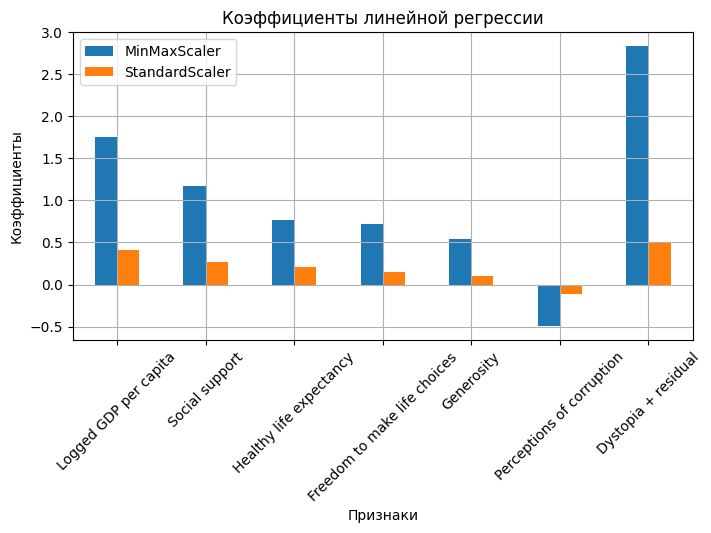

In [9]:
coef_lr = pd.DataFrame({
    'Признаки': X.columns,
    'MinMaxScaler': model_linreg_minmax.coef_,
    'StandardScaler': model_linreg_standard.coef_
})

coef_lr.plot(x='Признаки', kind='bar', figsize=(8, 4))

plt.title('Коэффициенты линейной регрессии')
plt.ylabel('Коэффициенты')
plt.xticks(rotation=45)
plt.grid()
plt.show()

**Ваш вывод здесь:**

После `StandardScaler` коэффициенты просто равномерно уменьшились, по сути они всё ещё так же соотносятся друг с другом как у до этого масштабирования, поэтому на качество модели это повлиять не должно.

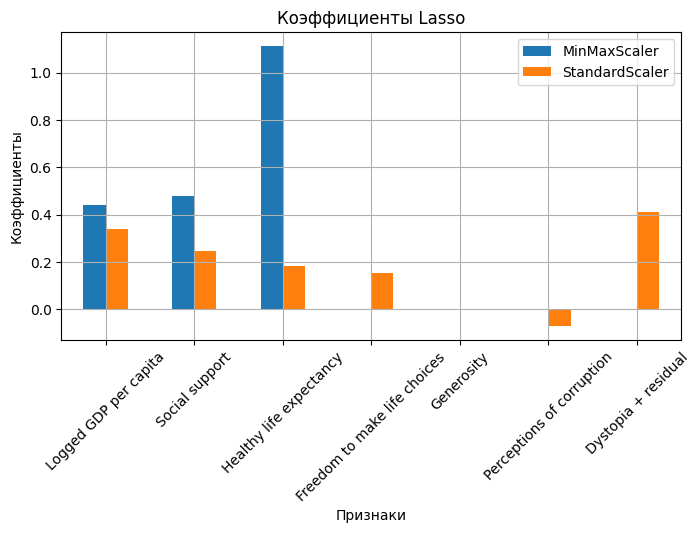

In [10]:
coef_lasso = pd.DataFrame({
    'Признаки': X.columns,
    'MinMaxScaler': model_lasso_minmax.coef_,
    'StandardScaler': model_lasso_standard.coef_
})

coef_lasso.plot(x='Признаки', kind='bar',figsize=(8, 4))

plt.title('Коэффициенты Lasso')
plt.ylabel('Коэффициенты')
plt.xticks(rotation=45)
plt.grid()
plt.show()

**Ваш вывод здесь:**

Коэффициенты признаков существенно изменились. Изначально многие коэффициенты были равны нули, из-за того что L1 регуляризация часто зануляет веса. После масштабирования `StandartScaler` значения принаков стали меньше и соответсвенно уменьшились коэффициенты. Однако модель перестала занулять некоторые изначально нулевые коэффициенты, так как теперь штраф от регуляризации не такой большой. 
В итоге изменение коэффициентов совершенно не такое равномерное, как это было у линейной регрессии.

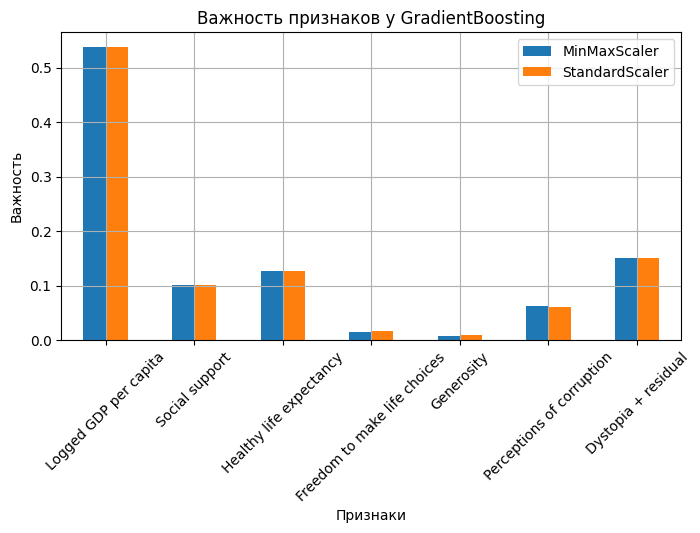

In [11]:
coef_gb = pd.DataFrame({
    'Признаки': X.columns,
    'MinMaxScaler': model_gb_minmax.feature_importances_,
    'StandardScaler': model_gb_standard.feature_importances_
})

coef_gb.plot(x='Признаки', kind='bar', figsize=(8, 4))

plt.title('Важность признаков у GradientBoosting')
plt.ylabel('Важность')
plt.xticks(rotation=45)
plt.grid()
plt.show()

**Ваш вывод здесь:**

Видно, что важность у признаков с `MinmaxScaler` и `StandardScaler` практически одинковая, что подтверждает тот факт, что масштаб признаков на качество модели деревьев не влияет.

### **Задание 3. (0.25 балла)**
Вернитесь к графику линейной регрессии. Очевидно, что коэффициенты одной модели связаны с коэффициентами другой. Как перейти от одних к другим? Реализуйте это в коде, как для свободного члена, так и для самих коэффициентов.

> Идея: коэффициенты линейной модели можно сравнивать как важности только при фиксированном масштабе. Вывод формулы перехода - способ строго показать, что коэффициенты меняются предсказуемо и не являются абсолютной важностью.

**Ваши теоретические выкладки здесь:**

![image](5204098275433192305.jpg)

In [12]:
coef_std = model_linreg_minmax.coef_ * sc_standard.scale_ / sc_minmax.data_range_
intercept_std = np.sum(model_linreg_minmax.coef_ * (sc_standard.mean_ - sc_minmax.data_min_) / sc_minmax.data_range_) + model_linreg_minmax.intercept_

assert round(intercept_std, 4) == round(model_linreg_standard.intercept_, 4)
assert all(np.round(coef_std, 4) == np.round(model_linreg_standard.coef_, 4))

## **1. Plot-based методы**

Рассмотрев тонкости работы с масштабированием, поработаем с plot-based методами. Оставьте теперь для анализа линейную регрессию и бустинг, обученные на MinMaxScaler.

In [13]:
lr_minmax =  model_linreg_minmax
gb_minmax =  model_gb_minmax

### **1. 1. ICE**

**Построение:**

1. Зафиксируем множество $X_{test}$ и некоторый признак $j$. Пусть  $j$ имеет $m$ уникальных значений $[j_1, j_2, ..., j_m]$.

2. Исходный датасет  $X_{test}$ дублируем  $m$ раз: $$X'_1, X'_2, ..., X'_m,$$ так, что для датасета $X'_i$ значение признака $j$ есть $j_i$;

3. На каждом $X'_i$ рассчитываем прогноз модели $f(X'_i)$&

4. На графике строим линии для каждого объекта, показывающие как прогноз (ось $y$) меняется при изменении признака (ось $x$);

### **Задание 4. (0.5 балла)**

Мы знаем, что признаки модели масштабированы определенным образом. Минимум каждого признака равен 0, максимум 1. Что будет с моделями, если признаки выйдут из диапазона?
- Работая с тем же признаком, изучите его **исходные** минимум и максимум. Сделайте искусственный диапазон из 20 точек, равный $[max, 3*max]$.
- На полученном диапазоне постройте ICE для обеих моделей. ICE стройте собственноручно, без использования sklearn.
- Зафиксируйте выводы


In [14]:
feature_min = X_test_sc_minmax[:, feature_idx].min()
feature_max = X_test_sc_minmax[:, feature_idx].max()

print(feature_min)
print(feature_max)

0.18653846153846154
0.9153846153846152


In [15]:
sample = np.linspace(feature_max, 3 * feature_max, 20)

X_lr = X_test_sc_minmax.copy()
X_gb = X_test_sc_minmax.copy()

lr_preds = []
gb_preds = []

for value in sample:
    X_lr[:, feature_idx] = value
    lr_pred = lr_minmax.predict(X_lr)
    lr_preds.append(lr_pred)

    X_gb[:, feature_idx] = value
    gb_pred = gb_minmax.predict(X_gb)
    gb_preds.append(gb_pred)

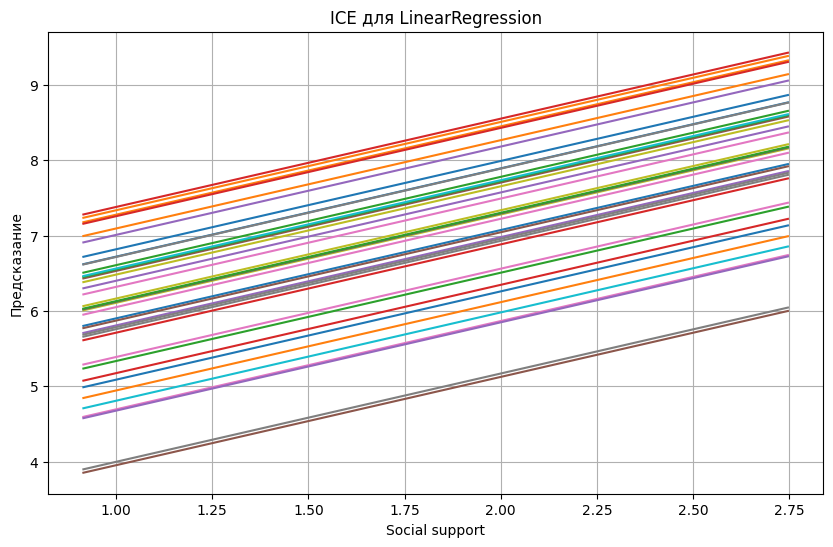

In [16]:
plt.figure(figsize=(10, 6))

for i in range(len(X_test_sc_minmax)):
    plt.plot(sample, np.array(lr_preds)[:, i])

plt.title(f'ICE для LinearRegression')
plt.xlabel(feature_name)
plt.ylabel('Предсказание')
plt.grid()
plt.show()

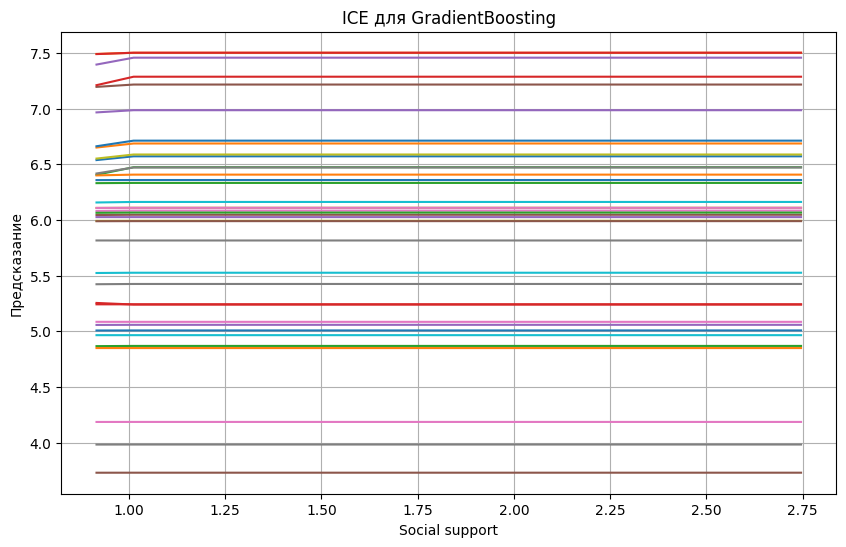

In [17]:
plt.figure(figsize=(10, 6))

for i in range(len(X_test_sc_minmax)):
    plt.plot(sample, np.array(gb_preds)[:, i])

plt.title(f'ICE для GradientBoosting')
plt.xlabel(feature_name)
plt.ylabel('Предсказание')
plt.grid()
plt.show()

**Ваш вывод здесь:**

При выходе значения признака из диапазона линейная регрессия и решающие деревья ведут себя по-разному. 

На графике ICE для решающих деревьев видим, что линии почти прямые. Так получилось, потому что деревья не умеют экстраполировать, так как все значения вне диапозона просто попадут в один и тот же лист, и модель выдаст одно и то же предсказание. 

Линейная регрессия экстраполировать может, потому что предсказание задаётся линейной формулой. Поэтому при росте значения признака просто росло предсказание и получались возрастающие прямые.

### **1. 2. PDP**

Теперь посмотрим на усредненнуе влияние признака.
### **Задание 5. (0.25 балла)**

- Усредните ICE по обеим моделям, используя PDP из sklearn.
- Сделайте выводы.


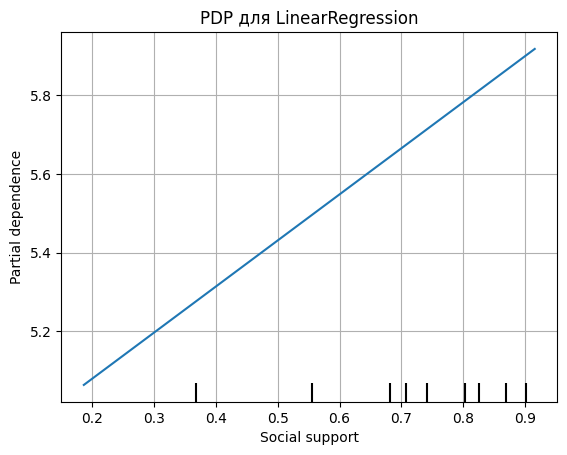

In [18]:
PartialDependenceDisplay.from_estimator(lr_minmax, X_test_sc_minmax, features=[feature_idx])

plt.title(f'PDP для LinearRegression')
plt.xlabel(feature_name)
plt.grid()
plt.show()

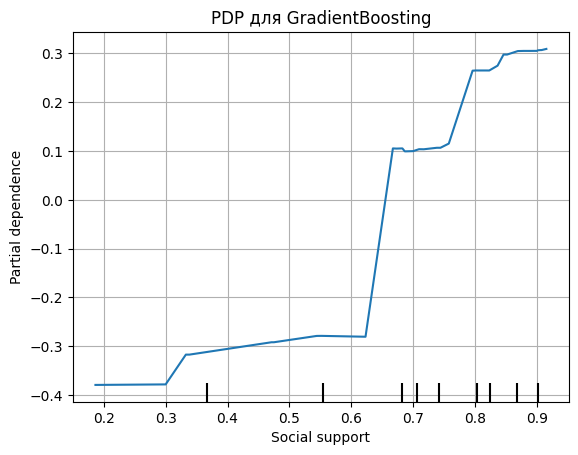

In [19]:
PartialDependenceDisplay.from_estimator(gb_minmax, X_test_sc_minmax, features=[feature_idx])

plt.xlabel(feature_name)
plt.title('PDP для GradientBoosting')
plt.grid()
plt.show()

**Ваш вывод здесь:**

Для `LinearRegression` PDP получается прямой линией, потому что модель линейная. То есть данная модель считает, что связь между таргетом и признаком линейная.

для `GradientBoosting` модель PDP получилась нелинейной и ступенчатой: модель особенно сильно меняет результат в некоторых диапазонах признака, а в других диапазонах влияния почти нет, что получается из-за разделений по порогам. То есть эта модель нашла уже более сложную зависисмость между признаком и таргетом

### **1. 3. Accumulated Local Effects (ALE)**

Заключительный из основных графических методов — ALE. Ради практики построим и его.

### **Задание 6. (0.5 балла)**

- Постройте ALE по обеим моделям, используя pyALE. (0.15)
- Подберите размер сетки так, чтобы получить доверительные интервалы. (0.05)
- Проанализируйте полученный график. Каковы получились ДИ? Почему они различны для моделей? (0.3)

> Важно: сетку значений строим в исходных единицах признака, но перед подачей в модель применяем тот же scaler, на котором обучение.

PyALE._ALE_generic:INFO: Continuous feature detected.


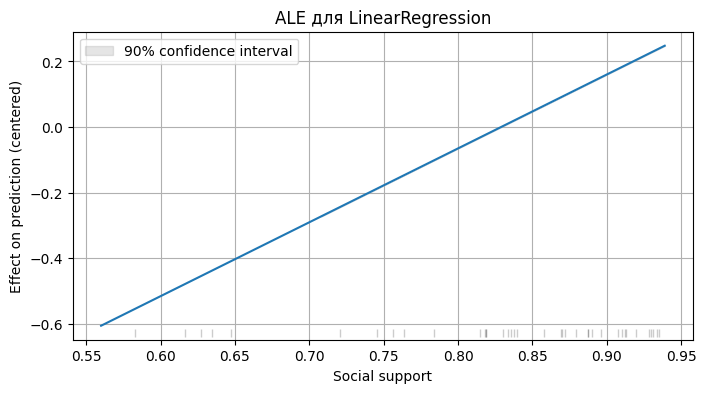

In [31]:
from PyALE import ale

def lr_predict(X):
    X_scaled = sc_minmax.transform(X)
    return model_linreg_minmax.predict(X_scaled)

lr_predict.predict = lr_predict

ale(
    X=X_test.copy(),
    model=lr_predict,
    feature=[feature_name],
    grid_size=8,
    C=0.9
)

plt.title('ALE для LinearRegression')
plt.grid()
plt.show()

PyALE._ALE_generic:INFO: Continuous feature detected.


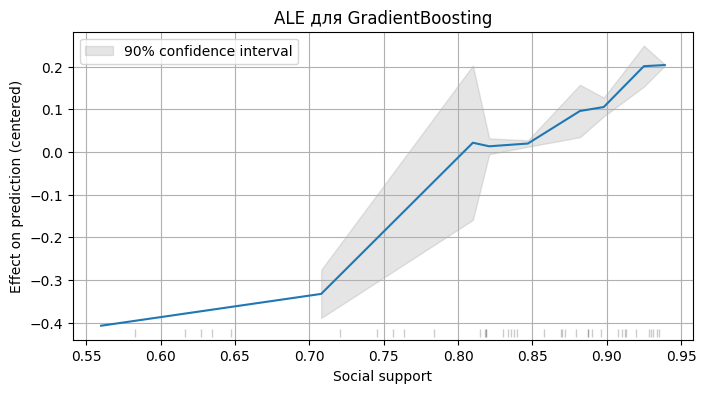

In [30]:
def gb_predict(X):
    X_scaled = sc_minmax.transform(X)
    return model_gb_minmax.predict(X_scaled)

gb_predict.predict = gb_predict

ale(
    X=X_test.copy(),
    model=gb_predict,
    feature=[feature_name],
    grid_size=8,
    C=0.9
)

plt.title('ALE для GradientBoosting')
plt.grid()
plt.show()

**Ваши выводы здесь:**

На графике для `LinearRegression` зависимость получилась почти линейной и стабильной. Это связано с тем, что линейная регрессия предполагает постоянный вклад признака в предсказание модели: при изменении значения признака его влияние на таргет меняется примерно одинаково. Доверительные интервалы у этой модели практически не видны, то есть они очень узкие. Это говорит о том, что модель оценивать локальный эффект признака стабильно, как это обычно и бывает у линейных регрессий из-за их строгой формулы зависимости

Для `GradientBoostingRegressor` график получился более сложным и нелинейным. Видно, что эффект признака меняется неравномерно: в некоторых диапазонах влияние усиливается, а в некоторых — ослабевает. Такая форма графика объясняется тем, что бустинг на деревьях способен учитывать сложные нелинейные взаимодействия между признаками.

Доверительные интервалы у бустинга заметно шире, особенно в области резкого изменений. Это означает, что в этих диапазонах локальный эффект признака менее устойчив и сильнее различается у объектов. Так получается, потому что деревья работают за счёт порогов и могут по-разному реагировать даже на близкие значения признаков.

## **2. Permutation importances**

Практикуем ещё один метод.
### **Задание 7. (0.25 балла)**

- Постройте Permutation importances по обеим моделям, используя sklearn
- Поэкспериментируйте с числом перестановок. (0.05)
- Проанализируйте полученные коэффициенты. Как они меняются от количества перестановок? Как меняются std коэффициентов? Зафиксируйте выводы. (0.20)

In [40]:
from sklearn.inspection import permutation_importance
import pandas as pd

repeats = [1, 5, 10, 30]

print('LinearRegression')

for n in repeats:
    print('Количество перестановок =', n)
    
    result_lr = permutation_importance(
        model_linreg_minmax,
        X_test_sc_minmax,
        y_test,
        n_repeats=n,
        random_state=42
    )
    
    df_lr = pd.DataFrame({
        'feature': X.columns,
        'importance_mean': result_lr.importances_mean,
        'importance_std': result_lr.importances_std
    })
    
    display(df_lr)

LinearRegression
Количество перестановок = 1


,feature,importance_mean,importance_std
0,Logged GDP per capita,0.258372,0.0
1,Social support,0.132619,0.0
2,Healthy life expectancy,0.109674,0.0
3,Freedom to make life choices,0.033046,0.0
4,Generosity,0.008583,0.0
5,Perceptions of corruption,0.018137,0.0
6,Dystopia + residual,0.852156,0.0


Количество перестановок = 5


,feature,importance_mean,importance_std
0,Logged GDP per capita,0.244970,0.035084
1,Social support,0.096987,0.021837
2,Healthy life expectancy,0.098432,0.012629
3,Freedom to make life choices,0.028175,0.003710
4,Generosity,0.009973,0.000763
5,Perceptions of corruption,0.022228,0.003888
6,Dystopia + residual,0.664757,0.128499


Количество перестановок = 10


,feature,importance_mean,importance_std
0,Logged GDP per capita,0.252710,0.037498
1,Social support,0.096048,0.017588
2,Healthy life expectancy,0.100739,0.013179
3,Freedom to make life choices,0.027834,0.004406
4,Generosity,0.010707,0.001191
5,Perceptions of corruption,0.022495,0.003189
6,Dystopia + residual,0.713678,0.152490


Количество перестановок = 30


,feature,importance_mean,importance_std
0,Logged GDP per capita,0.258673,0.036225
1,Social support,0.092405,0.015192
2,Healthy life expectancy,0.100830,0.015090
3,Freedom to make life choices,0.027054,0.004773
4,Generosity,0.010325,0.001489
5,Perceptions of corruption,0.022368,0.002803
6,Dystopia + residual,0.724167,0.129481


In [41]:
repeats = [1, 5, 10, 30]

print('GradientBoostingRegressor')

for n in repeats:
    print('Количество перестановок =', n)
    
    result_gb = permutation_importance(
        model_gb_minmax,
        X_test_sc_minmax,
        y_test,
        n_repeats=n,
        random_state=42
    )
    
    df_gb = pd.DataFrame({
        'feature': X.columns,
        'importance_mean': result_gb.importances_mean,
        'importance_std': result_gb.importances_std
    })
    
    display(df_gb)

GradientBoostingRegressor
Количество перестановок = 1


,feature,importance_mean,importance_std
0,Logged GDP per capita,0.415399,0.0
1,Social support,0.085656,0.0
2,Healthy life expectancy,0.046473,0.0
3,Freedom to make life choices,0.023933,0.0
4,Generosity,0.002268,0.0
5,Perceptions of corruption,-0.021093,0.0
6,Dystopia + residual,0.430080,0.0


Количество перестановок = 5


,feature,importance_mean,importance_std
0,Logged GDP per capita,0.369851,0.064861
1,Social support,0.054055,0.025151
2,Healthy life expectancy,0.031595,0.023190
3,Freedom to make life choices,0.011557,0.012122
4,Generosity,0.009595,0.005008
5,Perceptions of corruption,-0.034717,0.015810
6,Dystopia + residual,0.352423,0.089390


Количество перестановок = 10


,feature,importance_mean,importance_std
0,Logged GDP per capita,0.353502,0.065583
1,Social support,0.038272,0.031582
2,Healthy life expectancy,0.026968,0.025207
3,Freedom to make life choices,0.011503,0.009856
4,Generosity,0.006786,0.005257
5,Perceptions of corruption,-0.034755,0.017855
6,Dystopia + residual,0.405445,0.114640


Количество перестановок = 30


,feature,importance_mean,importance_std
0,Logged GDP per capita,0.380522,0.096503
1,Social support,0.029582,0.026681
2,Healthy life expectancy,0.026256,0.022804
3,Freedom to make life choices,0.012511,0.008950
4,Generosity,0.005692,0.005822
5,Perceptions of corruption,-0.041906,0.018106
6,Dystopia + residual,0.422219,0.093426


**Ваши выводы здесь:**

Полученные коэффициенты важности показывают, насколько в среднем падает качество модели при перемешивании признаков. В обеих моделях наиболее важными признаками были `Dystopia + residual` и `Logged GDP per capita`. Также заметный вклад дают `Social support` и `Healthy life expectancy`, но их importance_mean меньше.

Также видно, что у признака `Perceptions of corruption` результат получился отрицательным. Это означает, что после перемешивания этого признака качество модели даже немного улучшилось. Это означает, что такой признак модель использует нестабильно или он добавляет шум, в общем для модели он не очень важен.

Для линейной регрессии результаты достаточно стабильные. При увеличении числа перестановок значения немного меняются, но общий порядок важных признаков сохраняется. Это говорит о том, что линейная модель всегда показывает примерно одинаковую важность признаков, то есть она как обычно стабильна.

Для деревьев значения importance_mean меняются заметнее. Самыми важными также остаются `Dystopia + residual` и `Logged GDP per capita`, но их значения сильнее колеблются при разном числе перестановок. Эти значения меняется примерно от 0.35 до 0.43 (потому что случился выброс при 1 перестановке), что по сравнению с отальными коэффициентами значительный разброс. Это ожидаемо для бустинга, потому что модель нелинейная и сильнее зависит от разбиений данных.

Стандартные отклонения у линейной регрессии в целом небольшие, кроме `Dystopia + residual`, где разброс выше. У бустинга разброс заметно больше, особенно для наиболее важных признаков. Это означает, что оценки важности у этой модели менее стабильны и сильнее зависят от конкретной перестановки.

### **Задание 8. (0.5 балла)**

Идея перестановочной важности представляет собой частный случай важности при помощи внесения **возмущений** в признак. Возмущения могут быть разных видов:

- внесение случайного шума;
- зануление признака (удобно для изображений);
- сдвиг признака к его базовому значению и оценка траектории изменения прогнозов или качества модели;

В этом задании попробуем построить оценку на основе сдвига к базовому значению траектории. Примем за базовое значение медиану признака и будем сдвигать исходный признак к медианному с некоторым коэффициентом $\beta$:

$$x_j^{(\beta)}=(1-\beta)x_j+\beta b_j$$

где $b_j$ – медиана признака. Важность будем оценивать как изменение MSE по тест-данным.

1. Реализуйте это возмущение. Как меняются важности при разных $\beta$?
2. Постройте bar-график и сравните ранжирование с **permutation importance**. При сравнении, анализируйте только числовые признаки.


Для регрессии эффект очевиден, поэтому эту окклюзию оценивайте только для бустинга.
**Подсказка:**

1. Выберите базовые значения $x_j$ как **медианы по train** (базовые значения обозначим за $b_j$);
2. На тренировочном наборе данных для каждого признака $j$ замените столбец $x_j$ на $x^{(\beta)}_j=(1-\beta)x_j+\beta b_j$ при разных $\beta$, равных $[0.2, 0.5, 1]$.
3. Посчитайте $\Delta L_j = \text{MSE}(y,\hat y^{(\beta)}_j)-\text{MSE}(y,\hat y)$. Чем больше $\Delta L_j$, тем важнее признак.



In [42]:
def occlusion_importance():
    betas = [0.2, 0.5, 1]
    results = []

    y_pred = model_gb_minmax.predict(X_test_sc_minmax)
    mse = mean_squared_error(y_test, y_pred)

    medians = X_train.median()

    for beta in betas:
        for feature in X.columns:
            X_occ = X_test.copy()
            X_occ[feature] = (1 - beta) * X_occ[feature] + beta * medians[feature]
            X_occ_minmax = sc_minmax.transform(X_occ)

            y_pred_occ = model_gb_minmax.predict(X_occ_minmax)
            new_mse = mean_squared_error(y_test, y_pred_occ)

            results.append({
                'feature': feature,
                'beta': beta,
                'importance': new_mse - mse
            })

    return pd.DataFrame(results)

In [50]:
df_occ = occlusion_importance()

for beta in [0.2, 0.5, 1]:
    print('beta =', beta)
    display(df_occ[df_occ['beta'] == beta].sort_values('importance', ascending=False))

beta = 0.2


,feature,beta,importance
5,Perceptions of corruption,0.2,0.003037
2,Healthy life expectancy,0.2,0.002306
4,Generosity,0.2,0.000365
3,Freedom to make life choices,0.2,-0.000537
1,Social support,0.2,-0.008036
6,Dystopia + residual,0.2,-0.016533
0,Logged GDP per capita,0.2,-0.028717


beta = 0.5


,feature,beta,importance
7,Logged GDP per capita,0.5,0.063340
13,Dystopia + residual,0.5,0.045415
11,Generosity,0.5,0.004344
9,Healthy life expectancy,0.5,0.001121
10,Freedom to make life choices,0.5,-0.002015
8,Social support,0.5,-0.024894
12,Perceptions of corruption,0.5,-0.038174


beta = 1


,feature,beta,importance
20,Dystopia + residual,1.0,0.274894
14,Logged GDP per capita,1.0,0.146825
17,Freedom to make life choices,1.0,0.003381
18,Generosity,1.0,0.003162
16,Healthy life expectancy,1.0,-0.004931
15,Social support,1.0,-0.005913
19,Perceptions of corruption,1.0,-0.064080


При увеличении бета признаки сильнее сдвигаются к медиане, и модель теряет больше информации, а значения importance становятся более выраженными. При `beta = 0.2` изменения небольшие, поэтому важности близки к нулю. При `beta = 0.5` уже начинают выделяться наиболее важные признаки, а при `beta = 1` различия гораздо более ощутимы: сильнее всего растёт ошибка при изменении Dystopia + residual и Logged GDP per capita, то есть опять метод показал, что это самые важные признаки. 

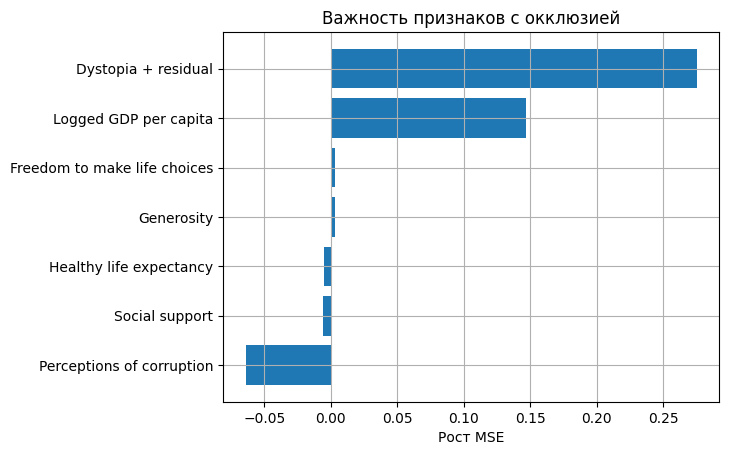

In [59]:
df_plot = df_occ[df_occ['beta'] == 1].sort_values('importance')

plt.barh(df_plot['feature'], df_plot['importance'])
plt.title('Важность признаков с окклюзией')
plt.xlabel('Рост MSE')
plt.grid()
plt.show()

In [60]:
df_perm = pd.DataFrame({
    'feature': X.columns,
    'permutation_importance': result_gb.importances_mean
})

compare_df = df_occ[df_occ['beta'] == 1][['feature', 'importance']]
compare_df = compare_df.rename(columns={'importance': 'occlusion_importance'})
compare_df = compare_df.merge(df_perm, on='feature')
compare_df = compare_df.sort_values('occlusion_importance',ascending=False)
compare_df

,feature,occlusion_importance,permutation_importance
6,Dystopia + residual,0.274894,0.422219
0,Logged GDP per capita,0.146825,0.380522
3,Freedom to make life choices,0.003381,0.012511
4,Generosity,0.003162,0.005692
2,Healthy life expectancy,-0.004931,0.026256
1,Social support,-0.005913,0.029582
5,Perceptions of corruption,-0.064080,-0.041906


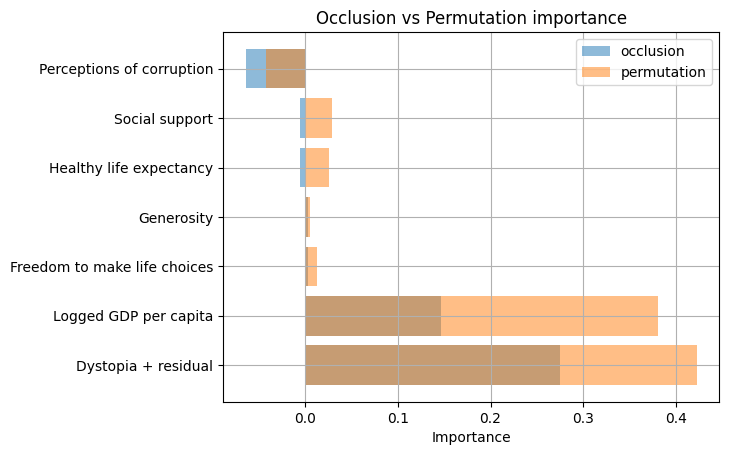

In [62]:
plt.barh(compare_df['feature'], compare_df['occlusion_importance'], alpha=0.5, label='occlusion')
plt.barh(compare_df['feature'], compare_df['permutation_importance'], alpha=0.5, label='permutation')
plt.title('Occlusion vs Permutation importance')
plt.xlabel('Importance')
plt.legend()
plt.grid()
plt.show()

**Ваши выводы здесь:**

Результаты этих двух методов в целом дают похожее ранжирование: в обоих методах самыми важными признаками были `Dystopia + residual` и `Logged GDP per capita`. При этом `permutation importance` даёт более высокие и в основном положительные значения, тогда как `occlusion importance` для некоторых признаков стало отрицательным. Скорее всего различия в значениях важности связаны с тем, что методы по-разному искажают признаки: `permutation importance` более радикально разрушает связи признаков с объектами, а `occlusion importance` изменяет значение более мягко, то есть заменяет на типичное значение.

## **3. SHAP**

Теперь проведем локальный анализ, используя SHAP и LIME. Но для shap также построим глобальные графики.

### **Задание 9. (0.5 баллa)**
- Постройте два глобальных графика, используя SHAP. Как один из них обязательно используйте `force`, как другой — выберите любой из документации. (0.25 балл)
- Проанализируйте важность признаков в обоих алгоритмах.(0.25 балл)

**NB:** Для линейного алгоритма используйте masker=`shap.maskers.Independent(data=X_train_sc)`. Он имитирует отсутствие признака

In [66]:
import shap

masker = shap.maskers.Independent(X_train_sc_minmax)
explainer_lr = shap.Explainer(model_linreg_minmax.predict, masker)
shap_lr = explainer_lr(X_test_sc_minmax)

In [67]:
shap.plots.force(shap_lr[0], feature_names=X.columns)

C:\Users\Asya-pc\AppData\Local\Temp\ipykernel_22892\2589476195.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_lr.values, X_test_sc_minmax, feature_names=X.columns)


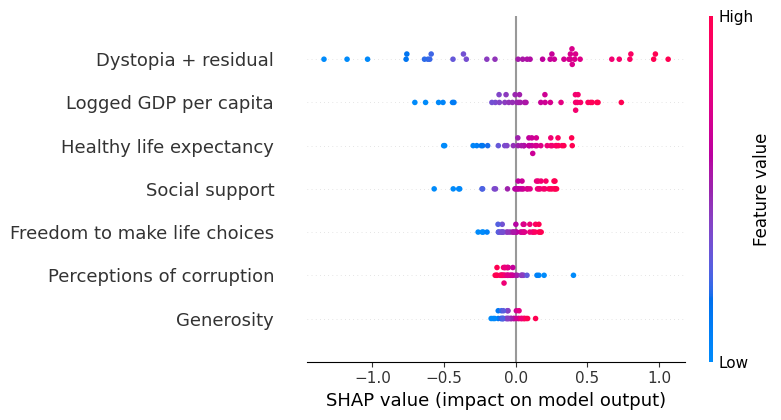

In [68]:
shap.summary_plot(shap_lr.values, X_test_sc_minmax, feature_names=X.columns)

In [71]:
explainer_gb = shap.Explainer(model_gb_minmax)
shap_gb = explainer_gb(X_test_sc_minmax)

In [72]:
shap.plots.force(shap_gb[0], feature_names=X.columns)

C:\Users\Asya-pc\AppData\Local\Temp\ipykernel_22892\3165009834.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_gb.values, X_test_sc_minmax, feature_names=X.columns)


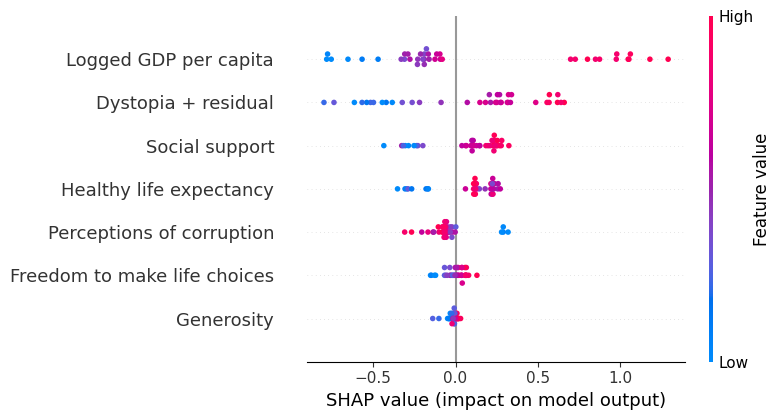

In [73]:
shap.summary_plot(shap_gb.values, X_test_sc_minmax, feature_names=X.columns)

 **Ваш вывод здесь:**

Для линейной регрессии наиболее важными признаками были `Dystopia + residual`, `Logged GDP per capita`, `Healthy life expectancy` и `Social support`. Судя по графику `summary_plot` высокие значения этих признаков чаще дают положительный вклад в прогноз модели. Также `summary_plot` для линейной регрессии выглядит достаточно упорядоченно, то есть все красные точки с одной стороны, а синие с другой, это связано с тем, что у линейной регрессии влияние признаков более стабильно.

Для бустинга наиболее важные признаки это тоже `Logged GDP per capita`, `Dystopia + residual`, `Social support` и `Healthy life expectancy`. При этом распределение  на `summary_plot` выглядит более неоднородным. Это связано с тем, что бустинг учитывает нелинейные зависимости между признаками, поэтому вклад одного и того же признака может заметно отличаться для разных объектов.

## **Локальное объяснение.**

### **Задание 10. (0.25 балла)**
- Постройте локальный график с SHAP для объекта с индексом 7 на обеих моделях и сделайте выводы.

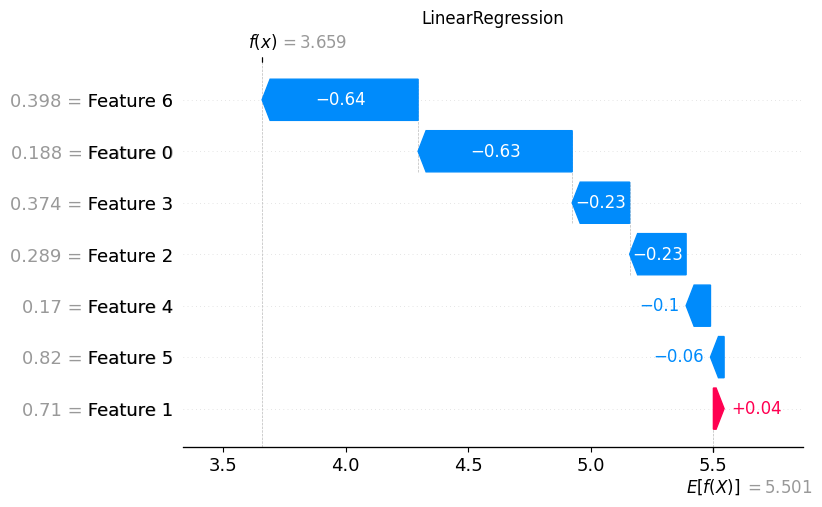

In [75]:
plt.title('LinearRegression')
shap.plots.waterfall(shap_lr[7])

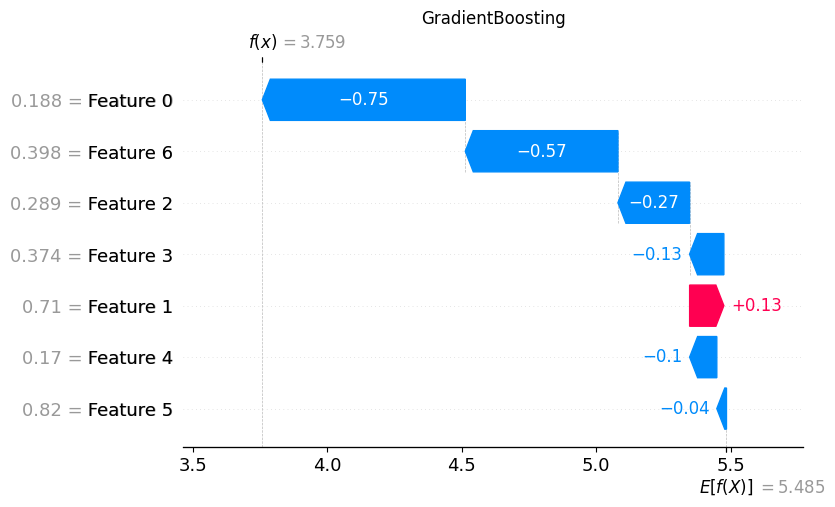

In [79]:
plt.title('GradientBoosting')
shap.plots.waterfall(shap_gb[7])

In [80]:
for i, col in enumerate(X.columns):
    print(i, col)

0 Logged GDP per capita
1 Social support
2 Healthy life expectancy
3 Freedom to make life choices
4 Generosity
5 Perceptions of corruption
6 Dystopia + residual


**Ваш вывод здесь:**

Для этого объекта обе модели дали похожие объяснения. Наибольший отрицательный вклад в прогноз внесли `Logged GDP per capita` и `Dystopia + residual`. Также отрицательно влияют `Healthy life expectancy` и `Freedom to make life choices`. Единственным признаком, который немного увеличивает результат у обеих моделей, был `Social support`.

При этом у бустинга вклады некоторых признаков более сильные и заметные, чем у линейной регрессии. Например, влияние `Logged GDP per capita` у бустинга более выражено (-0.75 против -0.63). Это опять связано с тем, что бустинг передаёт нелинейные зависимости и может по-разному оценивать вклад признаков для конкретных объектов. 

### **Теория: SHAP + categorical**


SHAP разлагает предсказание модели $f(x)$ на базовый уровень $\phi_0=\mathbb E[f(X)]$ и сумму вкладов признаков:

$$
f(x)=\phi_0+\sum_{j=1}^p \phi_j(x).
$$

Значение $\phi_j(x)$ — это «маржинальный вклад» признака $j$ вблизи точки $x$, усреднённый по всем коалициям признаков. Сумма SHAP по признакам всегда совпадает с предсказанием относительно базовой линии — отсюда удобство интерпретации и сравнимость вкладов.

Однако, вопреки этому удобству, SHAP имеет ограничения при работе с категориальными данными в разных кодировках.


1. OneHotEncoding. В этом случае каждому столбцу присвается свое значение Шепли. Общий вклад здесь — всегда **сумма** dummy-столбцов.
2. В CatBoost используется особый способ категориального разбиения, который (при использовании) фактически создаёт новые признаки для разбиения, отсутствующие в исходном наборе входных признаков. Эти признаки позволяют разбивать целые группы категорий тем или иным образом. Поддержка таких типов деревьев пока не реализована в SHAP, но можно использовать в CatBoost — встроенные [ShapValues](https://catboost.ai/docs/en/concepts/shap-values).
3. При других типах кодировок важно проверять отсутствие утечки.



## **4. LIME**

### **Задание 11. (0.25 балла)**
- Постройте локальный график с LIME для объекта с индексом 7 на обеих моделях и сделайте выводы. Сравните графики с SHAP. Ядро используйте как в семинаре — `kernel_width=np.sqrt(len(feature_names)) * 0.75`

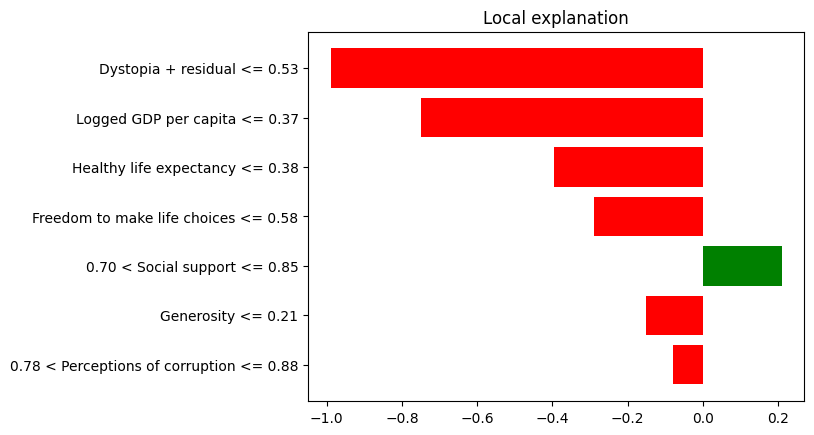

In [83]:
from lime.lime_tabular import LimeTabularExplainer

explainer_lr = LimeTabularExplainer(X_train_sc_minmax, feature_names=X.columns, mode='regression', 
                                    kernel_width=np.sqrt(len(X.columns)) * 0.75)

res_lr = explainer_lr.explain_instance(X_test_sc_minmax[7], model_linreg_minmax.predict)

res_lr.as_pyplot_figure()
plt.show()

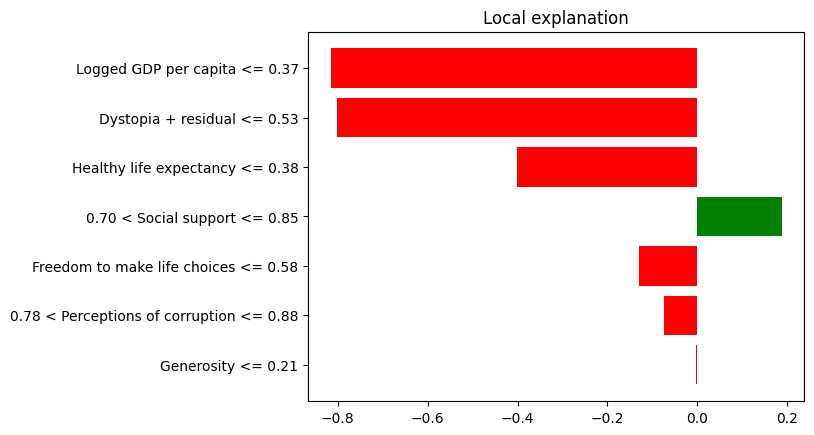

In [84]:
explainer_gb = LimeTabularExplainer(X_train_sc_minmax, feature_names=X.columns, mode='regression', 
                                    kernel_width=np.sqrt(len(X.columns)) * 0.75)

res_gb = explainer_gb.explain_instance(X_test_sc_minmax[7], model_gb_minmax.predict)

res_gb.as_pyplot_figure()
plt.show()

Нууу результаты похожи... не могу больше выводы писать((( я устала

Ладно, можно сказать, что LIME оценивает некоторые признаки как более сильне (те что с наибольшим вкладом), что как то связано стем, что LIME локально приближает модель вокруг объекта, то есть лучше учитывает особенности окрестности.

### **Задание 12. (1 балл)**

Теперь сделаем LIME собственноручно. Ваша реализация должна:

- Принимать на вход точку `x0`
- Вокруг этой точки данных сэмплировать окрестность заданного размера `n`
- На данных из этой окрестности получать прогнозы объясняемой модели (учитывать веса объектов, используя ядро)
- Обучать LIME модель в виде стандартной линейной регрессии
- Возвращать коэффициенты локальной модели


Для своей реализации оцените устойчивость. Как влияет на коэффициенты количество сгенерированных точек? А выбор ядра?

**В реализации вам может помочь библиотека `fatf`**
**Свой LIME тестируйте только для бустинга.**

In [ ]:
# Ваш код здесь — функция

In [ ]:
# Ваш код здесь применение на бустинге

 **Ваш вывод здесь:**

## **Вы проделали огромную работу! Ура!**